In [1]:
# imports
import datetime
import math
import time

import numpy as np
import pyodbc
import pandas as pd
from icecream import ic
from matplotlib import pyplot as plt
from pandas import DataFrame, Series
from pyodbc import Row

In [2]:
# functions
def time_to_seconds(_time: datetime.time) -> int:
    """
    params:
    _time in [00:00:00, 23:59:59]

    returns:
    out in [0, 86399]
    """
    return _time.hour * 3600 + _time.minute * 60 + _time.second


def seconds_to_time(total_seconds: int) -> datetime.time:
    """
    params:
    total_seconds in [0, 86399]

    returns:
    out in [00:00:00, 23:59:59]
    """
    if not (0 <= total_seconds < 86399):
        raise ValueError

    hour = total_seconds // 3600
    remaining_seconds = total_seconds % 3600

    minute = remaining_seconds // 60
    second = remaining_seconds % 60

    return datetime.time(hour=hour, minute=minute, second=second)


def stack_period(
    period: float | Series, size: float | Series, x: float | Series
) -> float | Series:
    """
    purchase_time:
        time user clicked buy

    purchase_time_s:
        purchase_time in seconds since start of day

    purchase_time_dow_s:
        purchase_time in seconds since start of week
        ((day_of_week - 1) * 86400) + purchase_time_s
    """
    return ((period - 1) * size) + x


def format_time_to_ms(_time: float) -> str:
    return f"{_time * 1000:.2f}ms"


def format_time(seconds: float) -> str:
    log_seconds: float = math.log10(seconds)

    match log_seconds:
        case _ if 0 <= log_seconds:
            return f"{seconds:.2f}s"

        case _ if -3 <= log_seconds < 0:
            return f"{seconds * 1000:.2f}ms"

        case _:
            return "<000.00ms"

In [3]:
# configs
name_map: dict[str, str] = {
    "dow": "day_of_week",
    "dom": "day_of_month",
    "doy": "day_of_year",
    "wn": "week_number",
    "mn": "month_number",
    "qn": "quarter_number",
    "yn": "year_number",
}


def sql_grain_pt(grain: str) -> str:
    return f"""
    SELECT
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
            AS diff_purchase_to_approve_s,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp),
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
    ORDER BY
        o.{grain},
        purchase_time,
        diff_purchase_to_approve_s
    """


sql_day_pt = """
    SELECT
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY CONVERT(TIME, o.order_purchase_timestamp)
    ORDER BY purchase_time;
"""

# connect
driver = "ODBC Driver 17 for SQL Server"
server = "localhost"
database = "olist"

connstring: str = f"""
    DRIVER={{{driver}}};
    SERVER={server};
    DATABASE={database};
    Trusted_Connection=yes;
"""
tik_connect = time.perf_counter()
conn = pyodbc.connect(connstring, timeout=60)
cursor = conn.cursor()
tok_connect = time.perf_counter()

# get day table
tik_day_table = time.perf_counter()
day_pt_rows: list[Row] = cursor.execute(sql_day_pt).fetchall()

day_pt_columns: list[str] = [description[0] for description in cursor.description]
df_day_pt: DataFrame = pd.DataFrame(
    (tuple(r) for r in day_pt_rows), columns=day_pt_columns
)
tok_day_table = time.perf_counter()

# get other tables
tik_other_tables = time.perf_counter()
dfs_pt: dict[str, DataFrame] = {}

for name in name_map:
    df_name = f"{name}"
    grain = name_map[name]

    sql = sql_grain_pt(grain=grain)
    grain_pt_rows: list[Row] = cursor.execute(sql).fetchall()

    grain_pt_columns: list[str] = [description[0] for description in cursor.description]
    df_grain_pt = pd.DataFrame(
        (tuple(r) for r in grain_pt_rows), columns=grain_pt_columns
    )

    dfs_pt[df_name] = df_grain_pt
tok_other_tables = time.perf_counter()

conn.close()

print(f"Time to connect to DB: {format_time_to_ms(tok_connect - tik_connect)}")
print(f"Query day table: {format_time_to_ms(tok_day_table - tik_day_table)}")
print(f"Query other tables: {format_time_to_ms(tok_other_tables - tik_other_tables)}")

Time to connect to DB: 74.10ms
Query day table: 340.33ms
Query other tables: 3145.79ms


In [4]:
# clean
time_s_column_name = "purchase_time_s"

tik_day = time.perf_counter()
if not df_day_pt.columns.str.contains(time_s_column_name).any():
    df_day_pt[time_s_column_name] = df_day_pt["purchase_time"].apply(time_to_seconds)
tok_day = time.perf_counter()

tik_other = time.perf_counter()
for i in dfs_pt:
    if not dfs_pt[i].columns.str.contains(time_s_column_name).any():
        dfs_pt[i][time_s_column_name] = dfs_pt[i]["purchase_time"].apply(
            time_to_seconds
        )

    if not dfs_pt[i].columns.str.contains("stack_s").any():
        dfs_pt[i]["stack_s"] = stack_period(
            dfs_pt[i][name_map[i]], 86400, dfs_pt[i][time_s_column_name]
        )
        pass


tok_other = time.perf_counter()

print(f"Clean df_pt_day: {format_time_to_ms(tok_day - tik_day)}")
print(f"Clean dfs_pt: {format_time_to_ms(tok_other - tik_other)}")

Clean df_pt_day: 23.43ms
Clean dfs_pt: 259.12ms


In [5]:
def time_ratio(chunk_size: str, whole: str = "d") -> float:
    """
    Solves the question: 'How many 15m chunks in a day?'
    How many {chunk_size} chunks in a {duration}
    Also: 'How many days in a 15m chunk'

    chunk_size format like: '15m', '1h', '12h'
    duration format like: 'd', '1d'
    """

    # measure to seconds
    day_in_s = 86400
    year_in_s = day_in_s * 365.25
    measures: dict[str, float] = {
        "s": 1,
        "m": 60,
        "h": 3600,
        "d": day_in_s,
        "w": day_in_s * 7,
        "M": year_in_s / 12,
        "q": year_in_s / 4,
        "y": year_in_s,
    }

    chunk_measure: str = chunk_size[-1]
    chunk_number_part: str = chunk_size[:-1]
    chunk_number: float = 1 if len(chunk_number_part) == 0 else float(chunk_number_part)

    whole_measure: str = whole[-1]
    whole_number_part: str = whole[:-1]
    whole_number: float = 1 if len(whole_number_part) == 0 else float(whole_number_part)

    chunk_number_in_s = chunk_number * measures[chunk_measure]
    whole_number_in_s = whole_number * measures[whole_measure]

    return whole_number_in_s / chunk_number_in_s


def bins_tr(*args) -> int:
    return math.floor(time_ratio(*args))

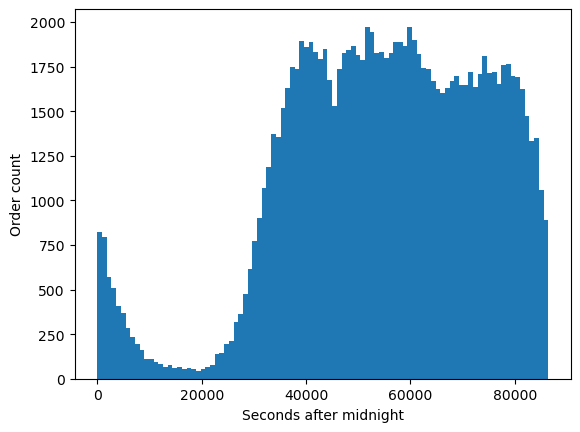

In [6]:
fig, ax = plt.subplots()

x = df_day_pt["purchase_time_s"]
weights = df_day_pt["order_count"]

ax.hist(x, weights=weights, bins=bins_tr("15m"))

ax.set_xlabel("Seconds after midnight")
ax.set_ylabel("Order count")
plt.show()

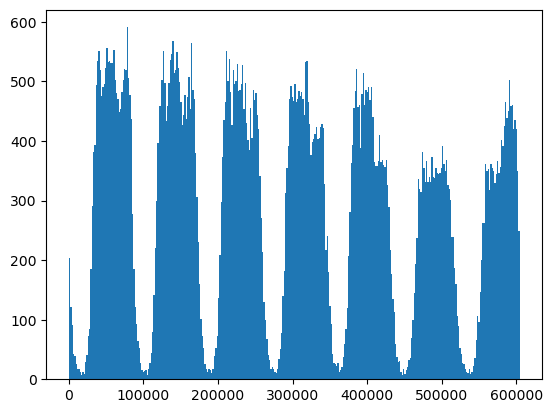

In [7]:
_data = dfs_pt["dow"]

x = _data["stack_s"]

fig, ax = plt.subplots()
ax.hist(x, bins=bins_tr("30m", "w"))

plt.show()

In [8]:
print(dfs_pt.keys())
dfs_pt["dow"]

dict_keys(['dow', 'dom', 'doy', 'wn', 'mn', 'qn', 'yn'])


,day_of_week,purchase_time,diff_purchase_to_approve_s,order_count,purchase_time_s,stack_s
0,1,00:00:01,914.0,1,1,1
1,1,00:00:01,1526.0,1,1,1
2,1,00:00:13,88497.0,2,13,13
3,1,00:00:29,1120.0,1,29,29
4,1,00:00:35,165496.0,1,35,35
...,...,...,...,...,...,...
98274,7,23:59:42,0.0,1,86382,604782
98275,7,23:59:44,182061.0,1,86384,604784
98276,7,23:59:45,6324.0,1,86385,604785
98277,7,23:59:54,926.0,1,86394,604794
